# Q6) Principal Component Analysis

Extracting XBP1 and GATA3 expression levels in all 105 patients, and generating the scatter plot as seen in 1a (coloring should be done by the class).

# a)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("filtered.tsv", sep="\t")
labels = pd.read_csv("class.tsv", sep="\t", header=None)
columns = pd.read_csv("columns.tsv", sep="\t", comment="#")

g1_id = columns[columns['GeneSymbol'] == 'GATA3']['ID'].values[0]
g2_id = columns[columns['GeneSymbol'] == 'XBP1']['ID'].values[0]

Here we extract the internal column identifiers for GATA3 and XBP1, and format them to match the column names in the data table (note the leading space).

In [3]:
g1_col = " " + str(g1_id)
g2_col = " " + str(g2_id)

x_vals = data[g1_col].values
y_vals = data[g2_col].values
class_vals = labels[0].values

x_vals: Expression values of GATA3.

y_vals: Expression values of XBP1.

class_vals: The class of each sample.

Two boolean masks (class0 and class1) identify samples in the ER- and ER+ classes, respectively.

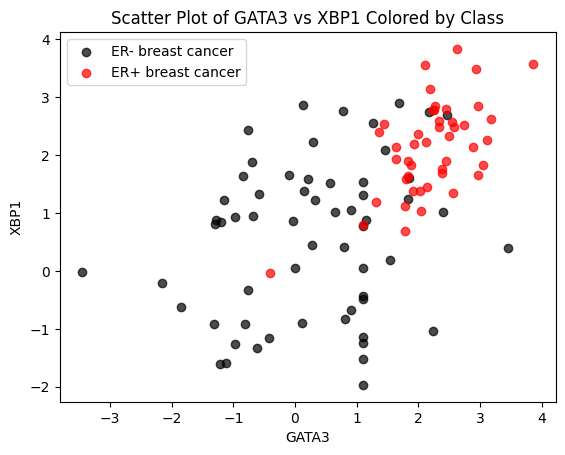

In [4]:
class0 = (class_vals == 0)
class1 = (class_vals == 1)

plt.scatter(x_vals[class0], y_vals[class0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(x_vals[class1], y_vals[class1], color='red', alpha=0.7, label='ER+ breast cancer')

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1 Colored by Class")
plt.legend()
plt.show()

We plot:

ER- samples in black.

ER+ samples in red.

# b)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

x = x_vals
y = y_vals
labels = class_vals

points = np.vstack((x, y)).T

x and y represent gene expression values for GATA3 and XBP1, respectively.

labels holds the class information (0 = ER-, 1 = ER+).

The gene data is stacked into a 2D array points of shape

In [7]:
mean = np.mean(points, axis=0)
centered = points - mean

We subtract the mean from each feature (gene) so that the data is centered around the origin. This is a standard preprocessing step for PCA.

In [8]:
cov = np.cov(centered.T)
e_vals, e_vecs = np.linalg.eig(cov)

idx = np.argsort(e_vals)[::-1]
e_vals = e_vals[idx]
e_vecs = e_vecs[:, idx]

The covariance matrix cov is calculated from the centered data.

Its eigenvalues (e_vals) and eigenvectors (e_vecs) are computed.

These are sorted in descending order of eigenvalues to prioritize the principal directions with the highest variance.

In [9]:
pcs = e_vecs.T
var = e_vals

group0 = (labels == 0)
group1 = (labels == 1)

pcs contains the principal components (direction vectors).

var holds the corresponding eigenvalues, which represent the amount of variance explained by each component.

pcs contains the principal components (direction vectors).

var holds the corresponding eigenvalues, which represent the amount of variance explained by each component.



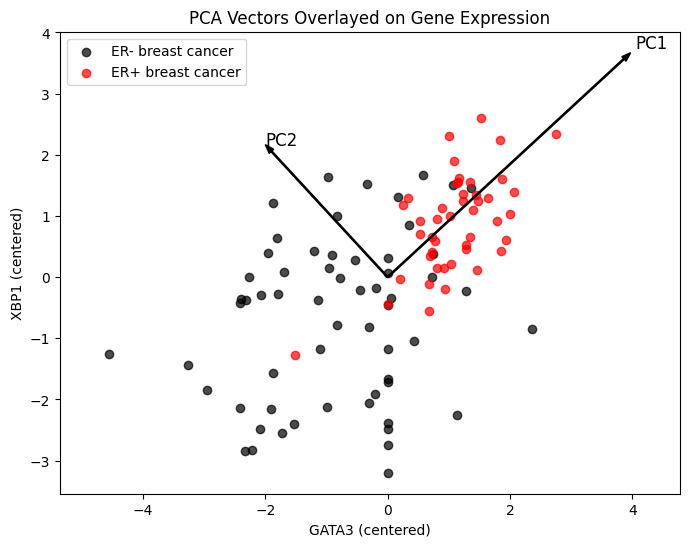

In [21]:

plt.figure(figsize=(8, 6))
plt.scatter(centered[group0, 0], centered[group0, 1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(centered[group1, 0], centered[group1, 1], color='red', alpha=0.7, label='ER+ breast cancer')

for i in range(2):
    x = pcs[i, 0] * np.sqrt(var[i]) * 3
    y = pcs[i, 1] * np.sqrt(var[i]) * 3
    plt.arrow(0, 0, x, y, color='black', width=0.02, head_width=0.1)
    plt.text(x * 1.05, y * 1.05, f'PC{i+1}', fontsize=12, color='black')

plt.xlabel("GATA3 (centered)")
plt.ylabel("XBP1 (centered)")
plt.title("PCA Vectors Overlayed on Gene Expression")
plt.legend()
plt.axis('equal')
plt.show()

A scatter plot is created using centered gene expression values.

Points are colored based on their class label.

Arrows are drawn from the origin to show the direction and magnitude of the two principal components.

The length of each vector is scaled by the square root of its eigenvalue to represent variance.

# c)

In [12]:
pc1 = e_vecs[:, 0]
proj = centered @ pc1

pc1 is the first principal component (eigenvector corresponding to the highest eigenvalue).

Each sample is projected onto this vector using a matrix multiplication (@).

The resulting proj vector contains 1D coordinates of each sample on PC1.



In [14]:
df_all = pd.DataFrame({
    "PC1": proj,
    "Group": "All",
    "Color": np.where(labels == 0, "black", "red")
})

df_0 = pd.DataFrame({
    "PC1": proj[labels == 0],
    "Group": "ER-",
    "Color": "black"
})

df_1 = pd.DataFrame({
    "PC1": proj[labels == 1],
    "Group": "ER+",
    "Color": "red"
})

A DataFrame df_all is created containing:

PC1 projection for all samples,

A "Group" label set to "All" for plotting purposes,

A "Color" field encoding class (black for ER-, red for ER+).

Similarly for other dataframes created.

In [15]:
df_plot = pd.concat([df_all, df_0, df_1], ignore_index=True)

The three DataFrames are merged into one for unified plotting.

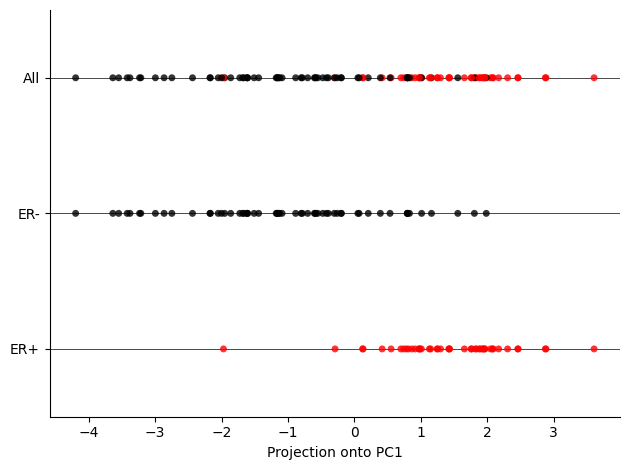

In [19]:
ax = sns.stripplot(data=df_plot, x="PC1", y="Group", hue="Color",
                   palette={"black": "black", "red": "red"},
                   dodge=False, jitter=False, alpha=0.8, size=5)
ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0)

plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

A stripplot is created using Seaborn:

X-axis: projection value on PC1,

Y-axis: sample group label (All, ER-, ER+),

Colored by class label (black = ER-, red = ER+),

Jitter adds randomness to avoid overlapping points,

dodge=False ensures all points stay within the same row.